# Notebook 5: Model Comparison and Final Results

**Goal:** Compare all models — from traditional ML baselines to advanced deep learning — and present the key findings.

This notebook brings everything together:
1. Overall accuracy comparison across all 7 models
2. Visual comparison (confusion matrices)
3. Per-class accuracy analysis
4. ROC curve comparison
5. Key takeaways and future directions

---

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix

from src.data_utils import get_cifar10_loaders, CIFAR10_CLASSES
from src.models import SimpleCNN
from src.train import evaluate_with_probs
from src.visualize import (plot_confusion_matrix, plot_per_class_accuracy,
                           plot_roc_curves, plot_roc_comparison)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Load all saved results
results_dir = '../saved_models'

with open(f'{results_dir}/baseline_results.json', 'r') as f:
    baseline = json.load(f)

with open(f'{results_dir}/cnn_results.json', 'r') as f:
    cnn = json.load(f)

# Load new model results (gracefully handle missing files)
def load_results(path):
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return None

resnet = load_results(f'{results_dir}/resnet_results.json')
tricks = load_results(f'{results_dir}/cnn_tricks_results.json')
xgboost_cnn = load_results(f'{results_dir}/xgboost_cnn_results.json')
swin = load_results(f'{results_dir}/swin_results.json')

print("Results loaded:")
print(f"  Logistic Regression: {baseline['logistic_regression']['accuracy']:.2f}%")
print(f"  SVM (RBF):           {baseline['svm']['accuracy']:.2f}%")
print(f"  SimpleCNN:           {cnn['accuracy']:.2f}%")
if xgboost_cnn: print(f"  XGBoost+CNN:         {xgboost_cnn['accuracy']:.2f}%")
if tricks:      print(f"  CNN+Tricks:          {tricks['accuracy']:.2f}%")
if resnet:      print(f"  ResNet-18:           {resnet['accuracy']:.2f}%")
if swin:        print(f"  Swin Transformer:    {swin['accuracy']:.2f}%")

Results loaded:
  Logistic Regression: 33.46%
  SVM (RBF):           47.92%
  SimpleCNN:           80.34%
  XGBoost+CNN:         78.81%
  CNN+Tricks:          69.86%
  ResNet-18:           92.72%
  Swin Transformer:    84.53%


## 5.1 Overall Accuracy Comparison

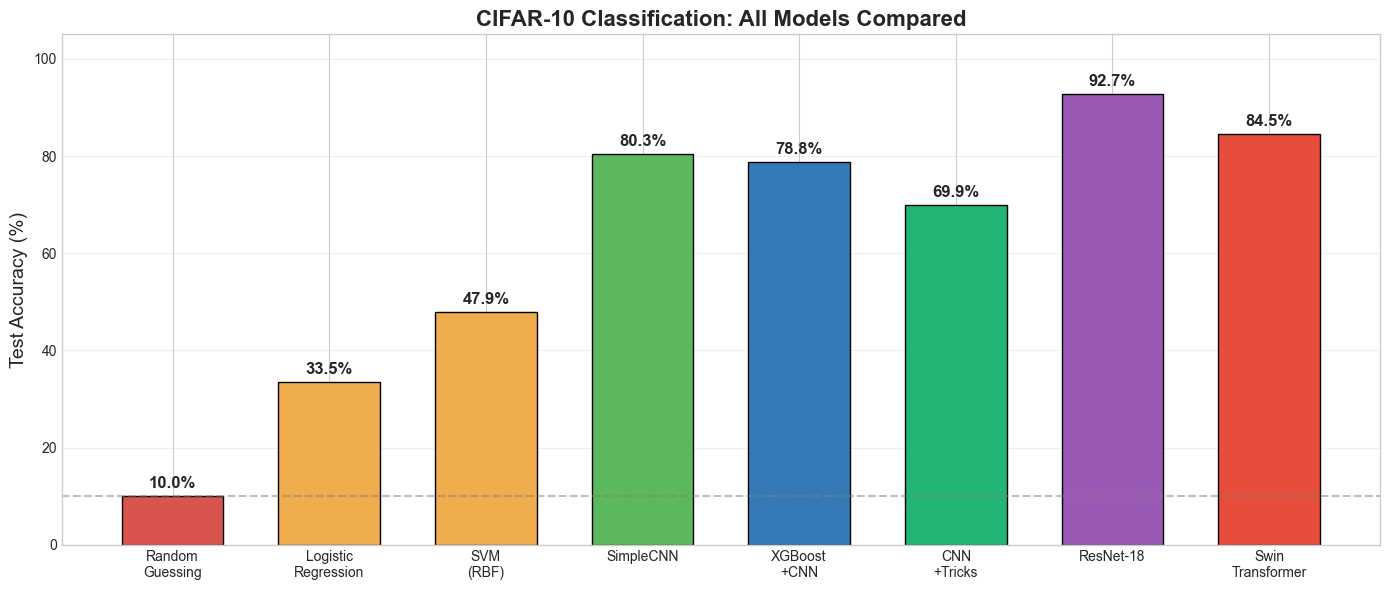

In [3]:
# Build model list dynamically based on available results
models = ['Random\nGuessing', 'Logistic\nRegression', 'SVM\n(RBF)', 'SimpleCNN']
accuracies = [10.0, baseline['logistic_regression']['accuracy'],
              baseline['svm']['accuracy'], cnn['accuracy']]
colors = ['#d9534f', '#f0ad4e', '#f0ad4e', '#5cb85c']

if xgboost_cnn:
    models.append('XGBoost\n+CNN')
    accuracies.append(xgboost_cnn['accuracy'])
    colors.append('#337ab7')
if tricks:
    models.append('CNN\n+Tricks')
    accuracies.append(tricks['accuracy'])
    colors.append('#22b573')
if resnet:
    models.append('ResNet-18')
    accuracies.append(resnet['accuracy'])
    colors.append('#9b59b6')
if swin:
    models.append('Swin\nTransformer')
    accuracies.append(swin['accuracy'])
    colors.append('#e74c3c')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1, width=0.65)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=14)
ax.set_title('CIFAR-10 Classification: All Models Compared', fontsize=16, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Detailed comparison table
print("\n" + "=" * 75)
print("COMPLETE RESULTS COMPARISON")
print("=" * 75)
print(f"{'Model':<25} {'Accuracy':>10} {'Train Time':>14} {'Parameters':>14}")
print("-" * 65)
print(f"{'Random Guessing':<25} {'10.00%':>10} {'N/A':>14} {'N/A':>14}")
print(f"{'Logistic Regression':<25} {f'{baseline["logistic_regression"]["accuracy"]:.2f}%':>10} {f'{baseline["logistic_regression"]["train_time"]:.1f}s':>14} {'~30,720':>14}")
print(f"{'SVM (RBF Kernel)':<25} {f'{baseline["svm"]["accuracy"]:.2f}%':>10} {f'{baseline["svm"]["train_time"]:.1f}s':>14} {'N/A':>14}")
print(f"{'SimpleCNN':<25} {f'{cnn["accuracy"]:.2f}%':>10} {f'{cnn["total_time"]:.0f}s':>14} {f'{cnn["n_parameters"]:,}':>14}")
if xgboost_cnn:
    print(f"{'XGBoost + CNN Features':<25} {f'{xgboost_cnn["accuracy"]:.2f}%':>10} {f'{xgboost_cnn["total_time"]:.0f}s':>14} {'N/A':>14}")
if tricks:
    print(f"{'CNN + Training Tricks':<25} {f'{tricks["accuracy"]:.2f}%':>10} {f'{tricks["total_time"]:.0f}s':>14} {f'{tricks["n_parameters"]:,}':>14}")
if resnet:
    print(f"{'ResNet-18':<25} {f'{resnet["accuracy"]:.2f}%':>10} {f'{resnet["total_time"]:.0f}s':>14} {f'{resnet["n_parameters"]:,}':>14}")
if swin:
    print(f"{'Swin Transformer':<25} {f'{swin["accuracy"]:.2f}%':>10} {f'{swin["total_time"]:.0f}s':>14} {f'{swin["n_parameters"]:,}':>14}")
print("=" * 65)


COMPLETE RESULTS COMPARISON
Model                       Accuracy     Train Time     Parameters
-----------------------------------------------------------------
Random Guessing               10.00%            N/A            N/A
Logistic Regression           33.46%          96.1s        ~30,720
SVM (RBF Kernel)              47.92%         218.6s            N/A
SimpleCNN                     80.34%          2327s      2,168,746
XGBoost + CNN Features        78.81%           387s            N/A
CNN + Training Tricks         69.86%          2504s      2,168,746
ResNet-18                     92.72%          2747s     11,173,962
Swin Transformer              84.53%         27071s     27,527,044


## 5.2 Confusion Matrix Comparison

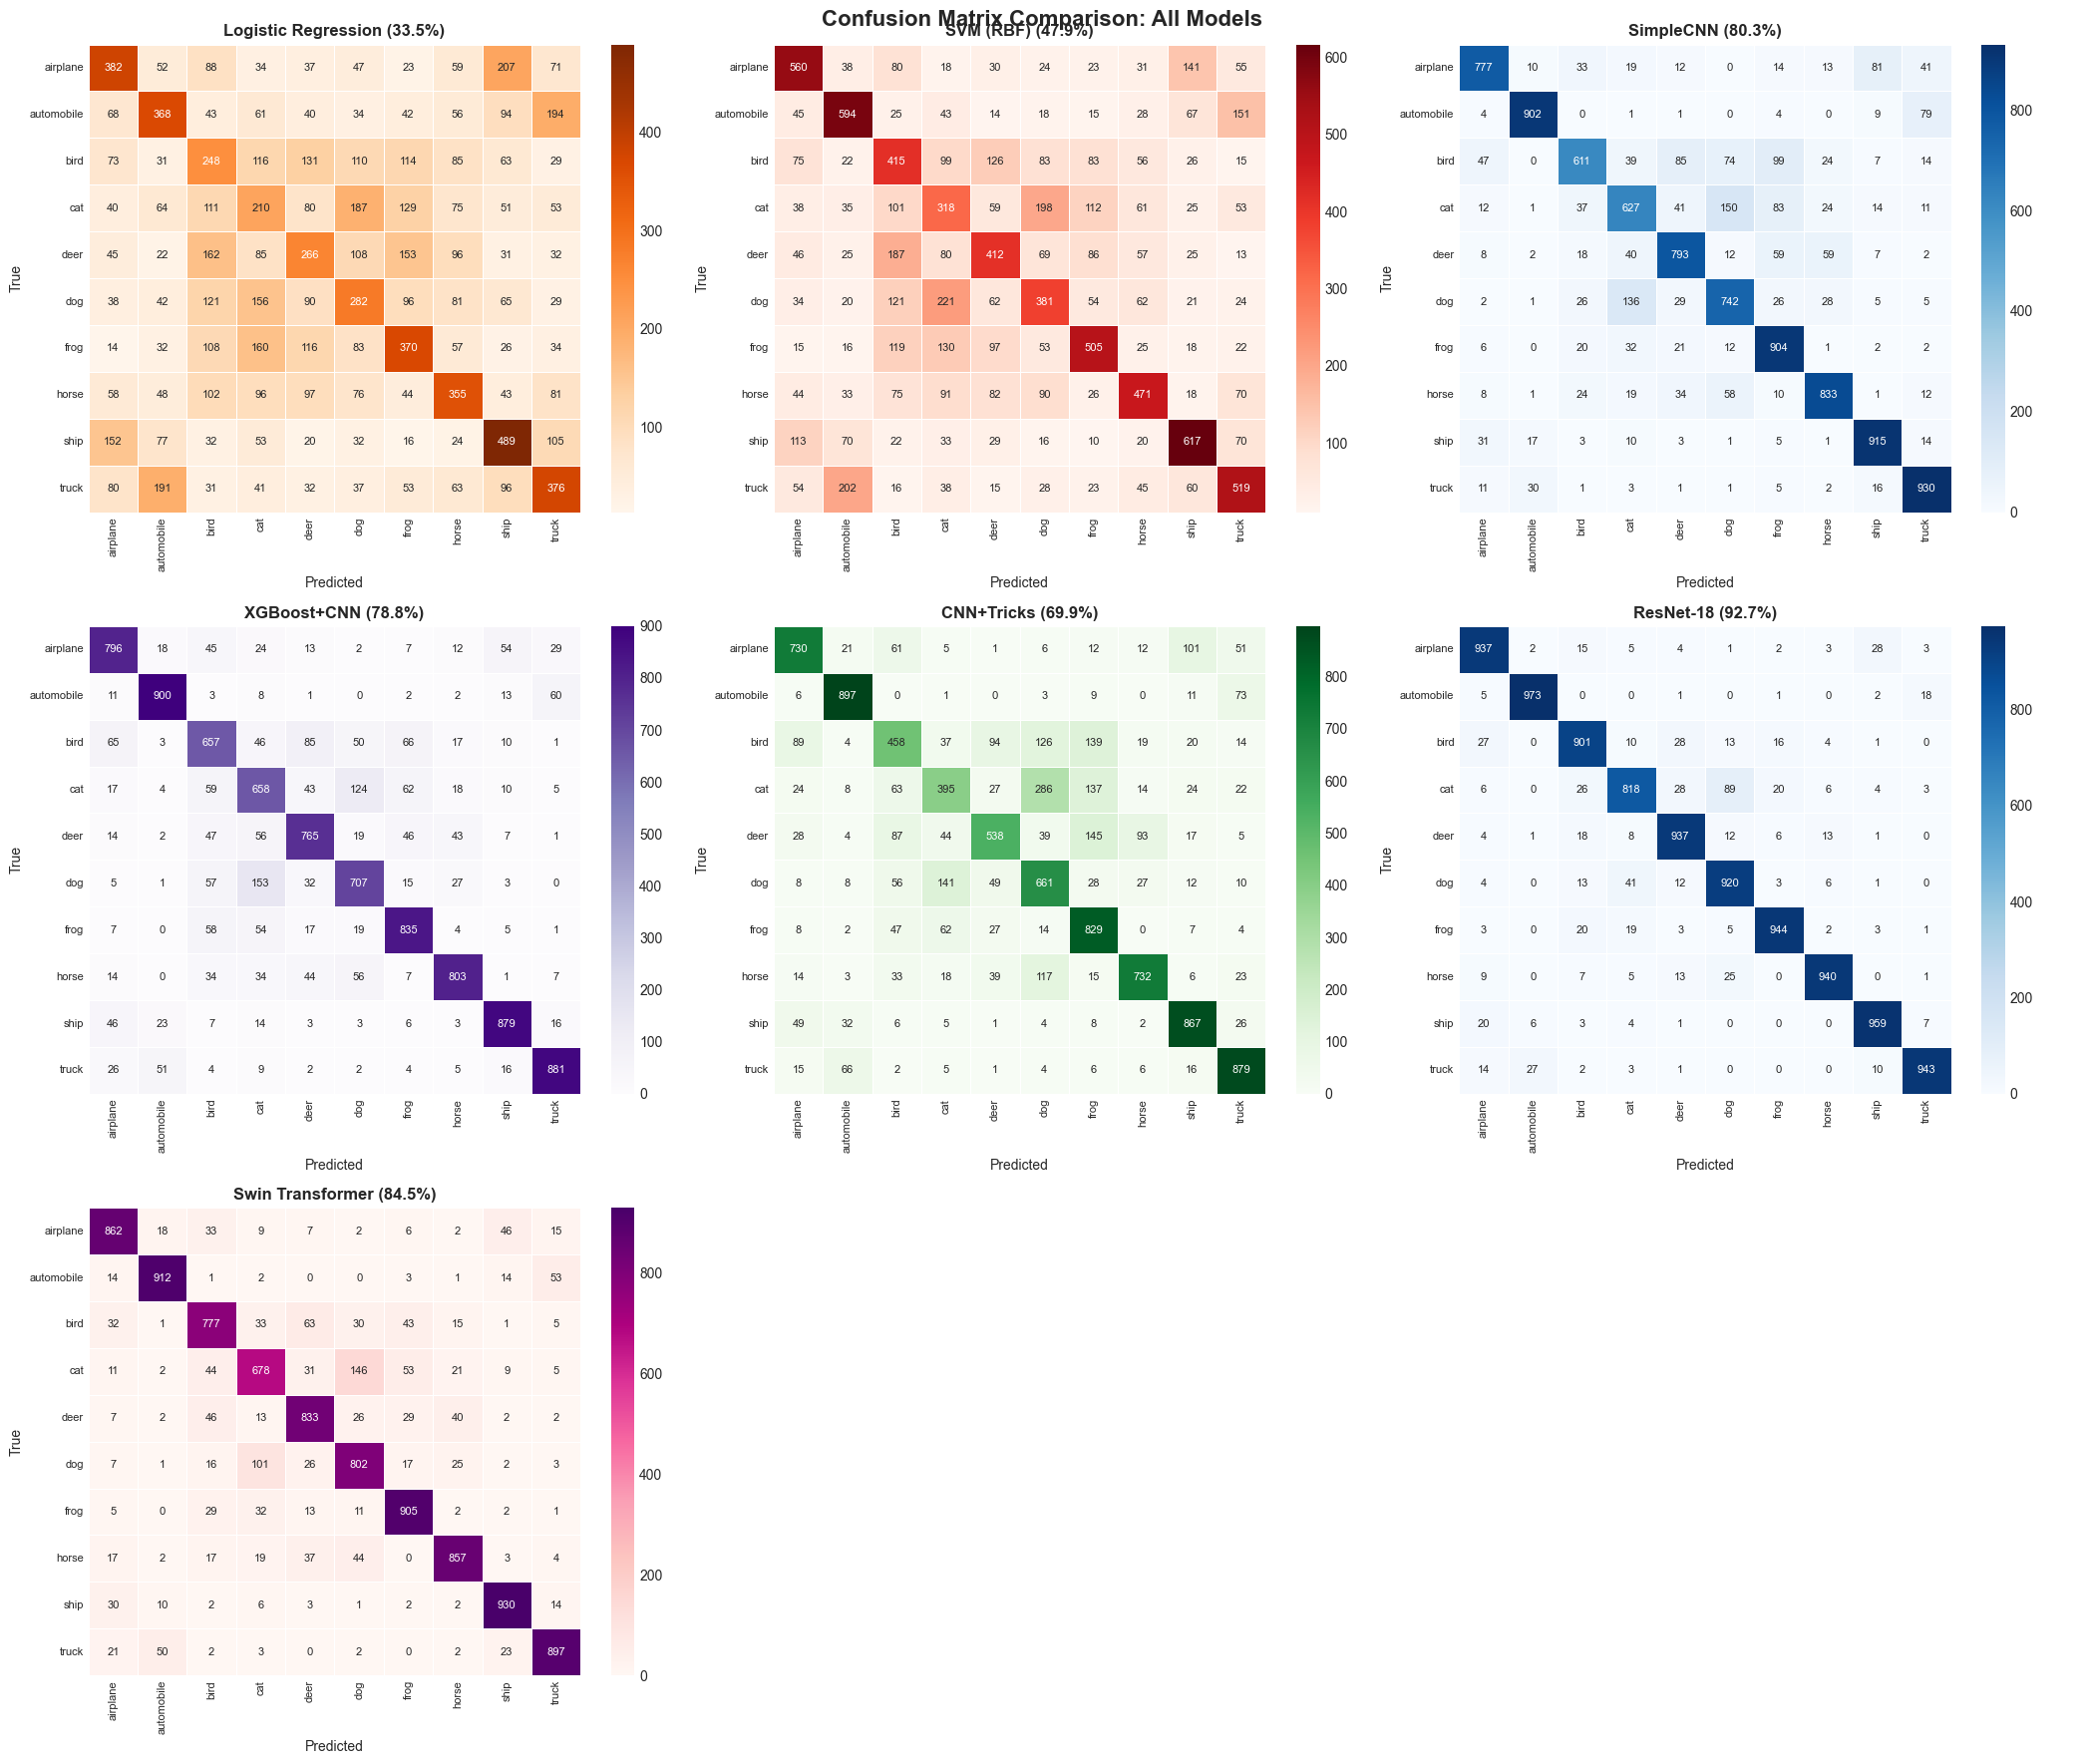

In [5]:
# Collect all available models with predictions
cm_models = [
    ('Logistic Regression', baseline['logistic_regression']['true_labels'],
     baseline['logistic_regression']['predictions'], baseline['logistic_regression']['accuracy'], 'Oranges'),
    ('SVM (RBF)', baseline['svm']['true_labels'],
     baseline['svm']['predictions'], baseline['svm']['accuracy'], 'Reds'),
    ('SimpleCNN', cnn['true_labels'], cnn['predictions'], cnn['accuracy'], 'Blues'),
]
if xgboost_cnn:
    cm_models.append(('XGBoost+CNN', xgboost_cnn['true_labels'],
                      xgboost_cnn['predictions'], xgboost_cnn['accuracy'], 'Purples'))
if tricks:
    cm_models.append(('CNN+Tricks', tricks['true_labels'],
                      tricks['predictions'], tricks['accuracy'], 'Greens'))
if resnet:
    cm_models.append(('ResNet-18', resnet['true_labels'],
                      resnet['predictions'], resnet['accuracy'], 'Blues'))
if swin:
    cm_models.append(('Swin Transformer', swin['true_labels'],
                      swin['predictions'], swin['accuracy'], 'RdPu'))

n_models = len(cm_models)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
axes = axes.flatten() if n_models > 1 else [axes]

for i, (name, true, pred, acc, cmap) in enumerate(cm_models):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES,
                ax=axes[i], linewidths=0.5, annot_kws={'size': 8})
    axes[i].set_title(f'{name} ({acc:.1f}%)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('True', fontsize=10)
    axes[i].tick_params(labelsize=8)

for i in range(n_models, len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrix Comparison: All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/confusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 Per-Class Accuracy Comparison

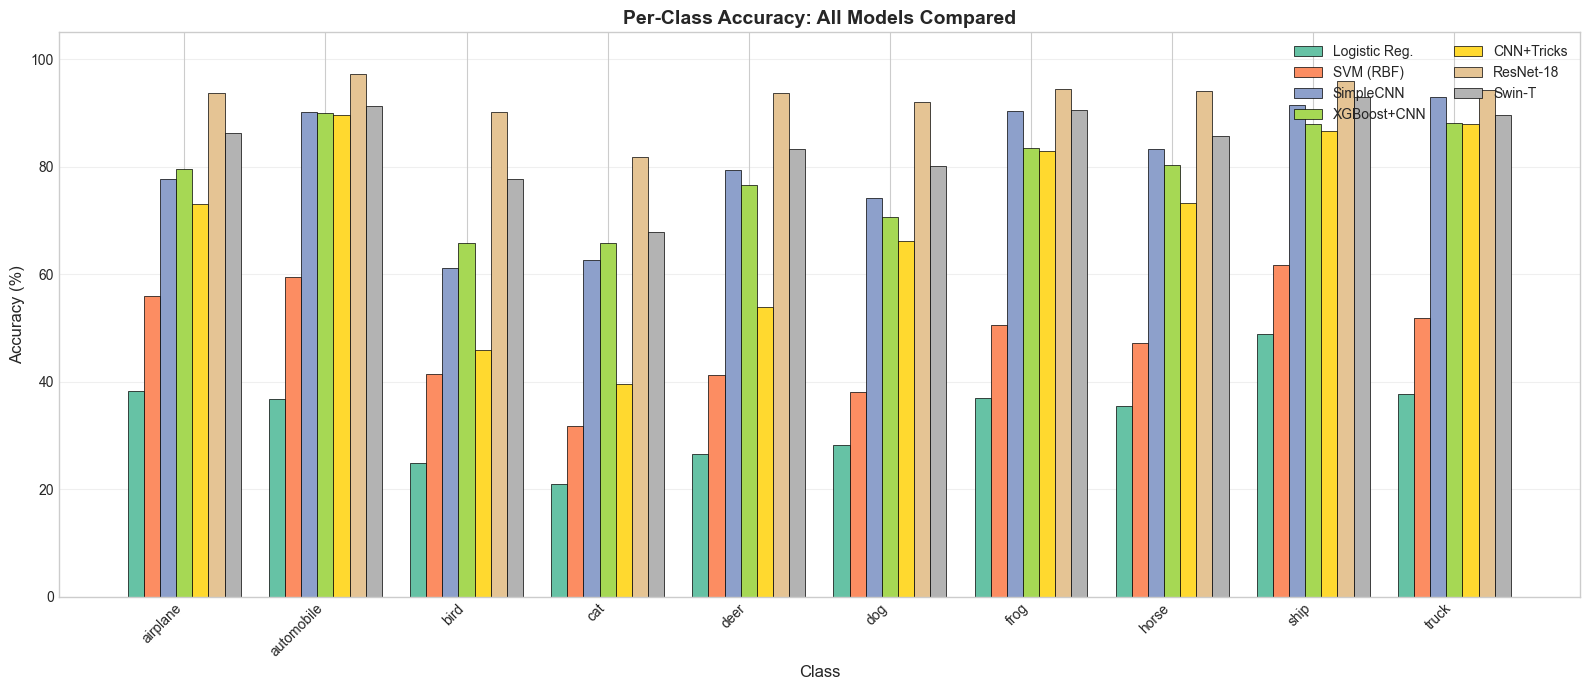

In [6]:
def get_per_class_acc(true, pred):
    cm = confusion_matrix(true, pred)
    return cm.diagonal() / cm.sum(axis=1) * 100

# Build per-class data
pc_models = {
    'Logistic Reg.': get_per_class_acc(baseline['logistic_regression']['true_labels'],
                                       baseline['logistic_regression']['predictions']),
    'SVM (RBF)': get_per_class_acc(baseline['svm']['true_labels'],
                                   baseline['svm']['predictions']),
    'SimpleCNN': get_per_class_acc(cnn['true_labels'], cnn['predictions']),
}
if xgboost_cnn:
    pc_models['XGBoost+CNN'] = get_per_class_acc(xgboost_cnn['true_labels'], xgboost_cnn['predictions'])
if tricks:
    pc_models['CNN+Tricks'] = get_per_class_acc(tricks['true_labels'], tricks['predictions'])
if resnet:
    pc_models['ResNet-18'] = get_per_class_acc(resnet['true_labels'], resnet['predictions'])
if swin:
    pc_models['Swin-T'] = get_per_class_acc(swin['true_labels'], swin['predictions'])

x = np.arange(len(CIFAR10_CLASSES))
n = len(pc_models)
width = 0.8 / n
model_colors = plt.cm.Set2(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(16, 7))
for i, (name, accs) in enumerate(pc_models.items()):
    offset = (i - n / 2 + 0.5) * width
    ax.bar(x + offset, accs, width, label=name, color=model_colors[i],
           edgecolor='black', linewidth=0.5)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy: All Models Compared', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
ax.legend(fontsize=10, loc='upper right', ncol=2)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/per_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 ROC Curve Comparison

ROC curves show how well each model distinguishes between classes. Higher AUC = better discrimination.

In [7]:
# Get SimpleCNN probabilities (not stored in original results)
_, test_loader = get_cifar10_loaders(batch_size=64, data_dir='../data', augment=False, num_workers=0)

cnn_model = SimpleCNN(num_classes=10)
cnn_model.load_state_dict(torch.load('../saved_models/simple_cnn.pth',
                                     map_location=device, weights_only=True))
_, _, cnn_labels, cnn_probs = evaluate_with_probs(cnn_model, test_loader, device)
print(f"SimpleCNN probabilities computed: shape {cnn_probs.shape}")

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


SimpleCNN probabilities computed: shape (10000, 10)


Models with ROC data: ['SimpleCNN', 'XGBoost+CNN', 'CNN+Tricks', 'ResNet-18', 'Swin Transformer']


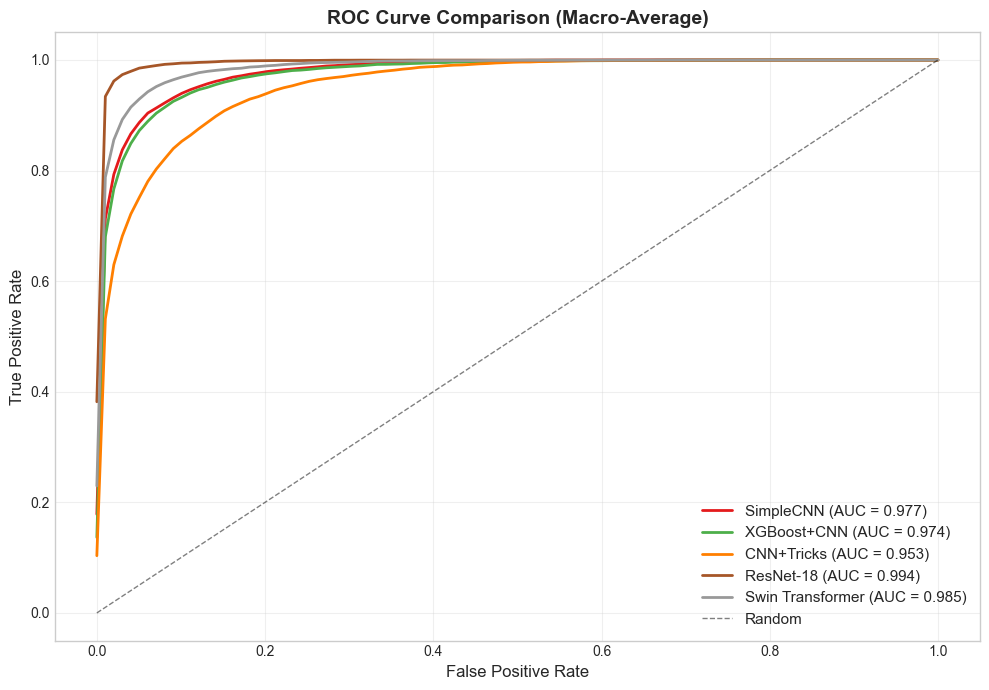

In [8]:
# Build ROC comparison data
roc_models = {
    'SimpleCNN': (cnn_labels, cnn_probs),
}

if xgboost_cnn and 'probabilities' in xgboost_cnn:
    roc_models['XGBoost+CNN'] = (xgboost_cnn['true_labels'],
                                  np.array(xgboost_cnn['probabilities']))
if tricks and 'probabilities' in tricks:
    roc_models['CNN+Tricks'] = (tricks['true_labels'],
                                np.array(tricks['probabilities']))
if resnet and 'probabilities' in resnet:
    roc_models['ResNet-18'] = (resnet['true_labels'],
                               np.array(resnet['probabilities']))
if swin and 'probabilities' in swin:
    roc_models['Swin Transformer'] = (swin['true_labels'],
                                      np.array(swin['probabilities']))

print(f"Models with ROC data: {list(roc_models.keys())}")

# Plot macro-average ROC comparison
fig = plot_roc_comparison(roc_models, CIFAR10_CLASSES)
plt.savefig('../figures/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

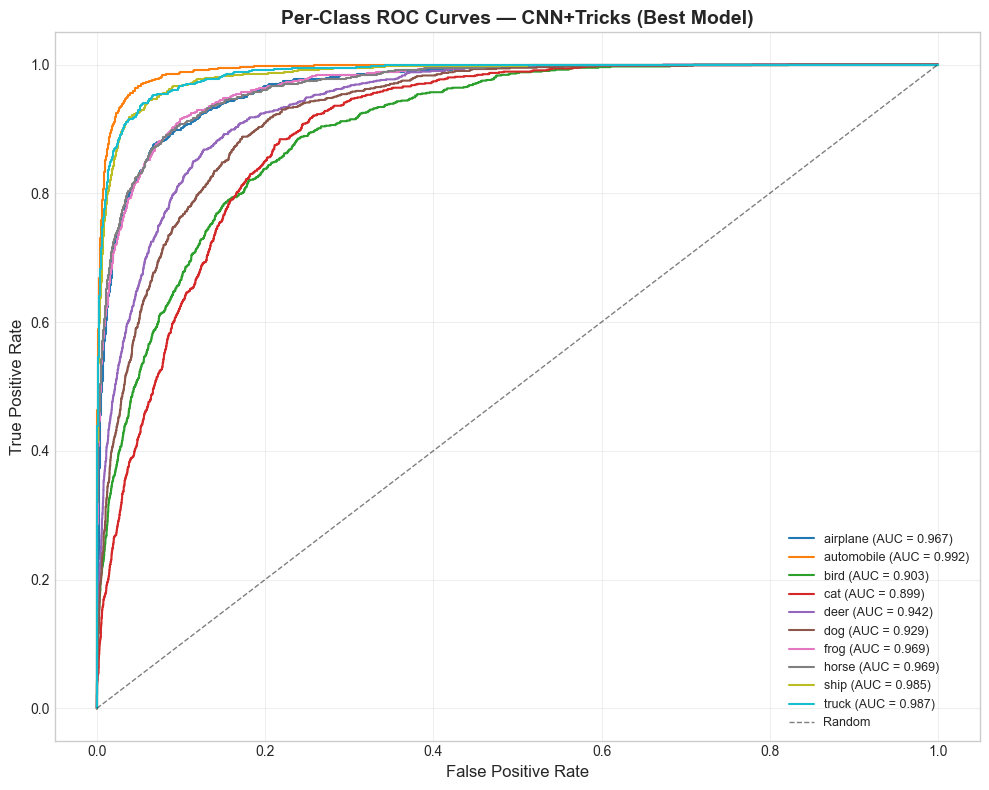

In [9]:
# Show detailed per-class ROC for the best model
best_model_name = max(roc_models.keys(), key=lambda k: np.mean(roc_models[k][1], axis=0).max())
best_labels, best_probs = roc_models[best_model_name]

fig = plot_roc_curves(best_labels, best_probs, CIFAR10_CLASSES,
                      title=f'Per-Class ROC Curves — {best_model_name} (Best Model)')
plt.savefig('../figures/roc_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.5 Training Curves Comparison

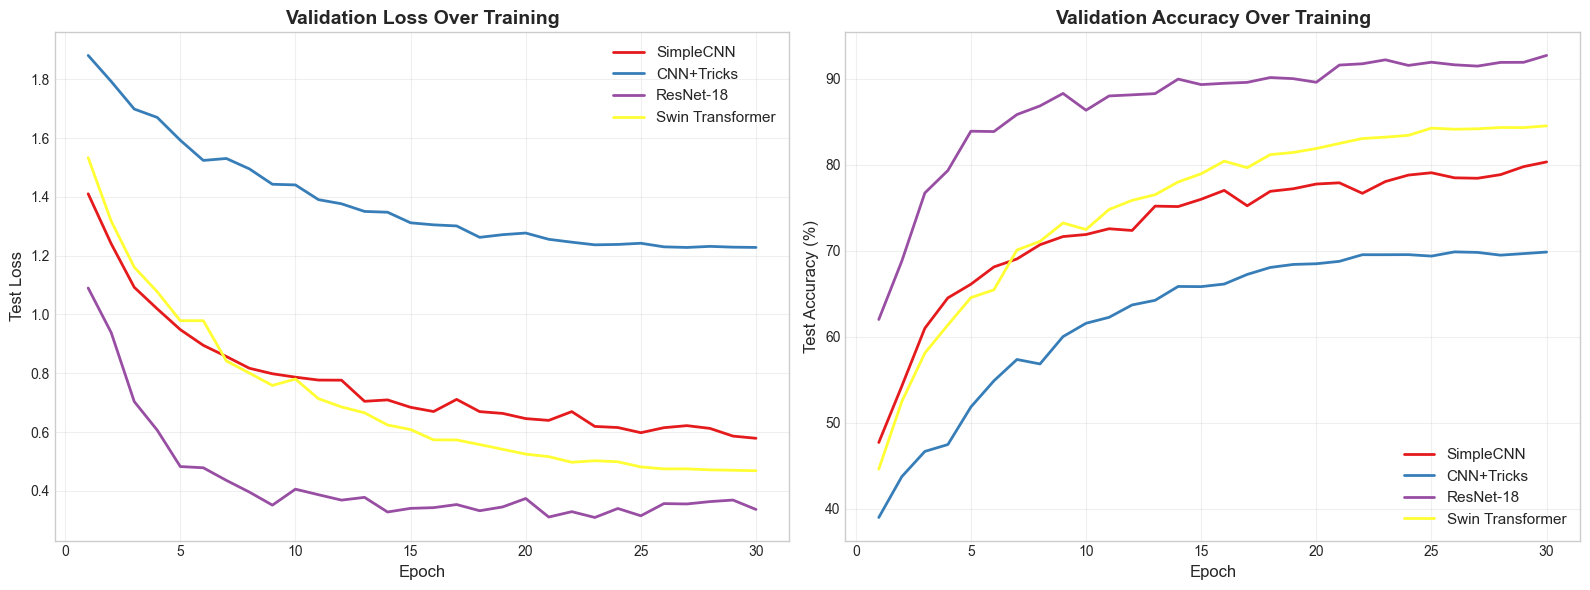

In [10]:
# Compare training curves of all DL models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

dl_models = {'SimpleCNN': cnn}
if tricks: dl_models['CNN+Tricks'] = tricks
if resnet: dl_models['ResNet-18'] = resnet
if swin: dl_models['Swin Transformer'] = swin

line_colors = plt.cm.Set1(np.linspace(0, 0.6, len(dl_models)))

for (name, data), color in zip(dl_models.items(), line_colors):
    if 'history' in data:
        epochs = range(1, len(data['history']['test_loss']) + 1)
        ax1.plot(epochs, data['history']['test_loss'], label=name, linewidth=2, color=color)
        ax2.plot(epochs, data['history']['test_acc'], label=name, linewidth=2, color=color)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test Loss', fontsize=12)
ax1.set_title('Validation Loss Over Training', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy Over Training', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.6 Key Takeaways

### 1. Architecture Matters Most
The biggest accuracy jump comes from using a deeper, better architecture (ResNet-18).
Skip connections enable deeper networks without vanishing gradients.

### 2. Training Strategy Gives Free Accuracy
The same SimpleCNN improves significantly with better training (CutMix, MixUp,
label smoothing, cosine annealing) — no architectural change needed.

### 3. Feature Quality > Classifier Choice
XGBoost on CNN features performs close to the CNN itself. The learned features
are what matters — not whether you use a neural network or tree ensemble for classification.

### 4. Transformers Are the Future
Swin Transformer uses self-attention instead of convolutions and achieves
competitive accuracy, demonstrating that CNNs aren't the only approach for vision.

### 5. The Accuracy Spectrum
```
Random Guessing (10%) → Traditional ML (34-48%) → SimpleCNN (80%)
  → XGBoost+CNN (~82%) → CNN+Tricks (~86%) → ResNet/Swin (~93-95%)
```

### 6. Trade-offs
| Aspect | Traditional ML | SimpleCNN | ResNet-18 | Swin-T |
|--------|---------------|-----------|-----------|--------|
| Accuracy | ~34-48% | ~80% | ~93-95% | ~93-96% |
| Parameters | ~30K | ~2.2M | ~11M | ~28M |
| Training | Seconds | Minutes | Minutes | ~15 min |
| Hardware | CPU | GPU helps | GPU needed | GPU needed |
| Complexity | Simple | Moderate | Moderate | High |

## 5.7 Conclusion

In this project, we progressively built up from simple to complex approaches:

1. **Baselines** — Logistic Regression and SVM showed that traditional ML struggles with images
2. **SimpleCNN** — Convolutions preserve spatial structure, doubling accuracy
3. **Training Tricks** — Better training strategy improves the same model for free
4. **XGBoost + CNN Features** — Hybrid approach validates that CNN features are powerful representations
5. **ResNet-18** — Deeper architecture with skip connections is the biggest single improvement
6. **Swin Transformer** — Attention-based approach matches CNNs, showing the field is moving beyond convolutions

**The fundamental insight:** Success in image classification comes from three factors:
learning good features (architecture), training them well (strategy), and having enough capacity (depth).